In [60]:
%matplotlib inline 
from pyknon.genmidi import Midi
from pyknon.music import NoteSeq
from qiskit import IBMQ
from qiskit import *
from qiskit.visualization import plot_state_city, plot_histogram
from qiskit.tools.monitor import job_monitor
import numpy as np

In [53]:
IBMQ.load_account()

<AccountProvider for IBMQ(hub='ibm-q', group='open', project='main')>

In [54]:
IBMQ.providers()

[<AccountProvider for IBMQ(hub='ibm-q', group='open', project='main')>]

In [55]:
provider = IBMQ.get_provider(group="open")

In [57]:
provider.backends()

[<IBMQSimulator('ibmq_qasm_simulator') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmqx2') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_16_melbourne') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_vigo') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_ourense') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_london') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_burlington') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_essex') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_armonk') from IBMQ(hub='ibm-q', group='open', project='main')>]

In [59]:
backend = provider.get_backend("ibmq_london")

In [8]:
notes1 = NoteSeq("D4 F#8 A Bb4")
midi = Midi(1, tempo=90)
midi.seq_notes(notes1, track=0)
midi.write("demo.mid")

In [9]:
!timidity demo.mid

Requested buffer size 32768, fragment size 8192
ALSA pcm 'default' set buffer size 32768, period size 8192 bytes
Playing demo.mid
MIDI file: demo.mid
Format: 1  Tracks: 1  Divisions: 128
Sequence: Track 0
Playing time: ~6 seconds
Notes cut: 0
Notes lost totally: 0


In [42]:
sheet = QuantumCircuit(3, 3)

sheet.h(0)
sheet.h(1)
sheet.h(2)

sheet.barrier(range(3))
sheet.measure(range(3), range(3))

sheet.draw()

┌───┐ ░ ┌─┐      
q_0: |0>┤ H ├─░─┤M├──────
        ├───┤ ░ └╥┘┌─┐   
q_1: |0>┤ H ├─░──╫─┤M├───
        ├───┤ ░  ║ └╥┘┌─┐
q_2: |0>┤ H ├─░──╫──╫─┤M├
        └───┘ ░  ║  ║ └╥┘
 c_0: 0 ═════════╩══╬══╬═
                    ║  ║ 
 c_1: 0 ════════════╩══╬═
                       ║ 
 c_2: 0 ═══════════════╩═

In [61]:
job = execute(sheet, backend=backend, shots=1024)

In [62]:
job_monitor(job)

Job Status: job has successfully run


In [63]:
result = job.result()

In [64]:
counts = result.get_counts(sheet)

In [65]:
print(counts)

{'011': 133, '000': 137, '001': 160, '010': 139, '111': 89, '101': 133, '110': 116, '100': 117}


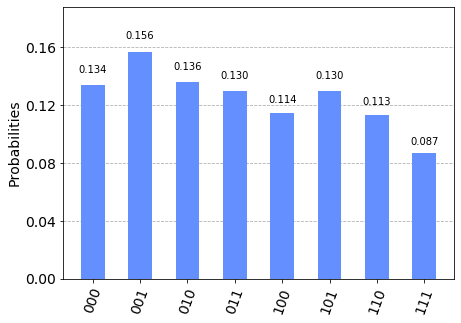

In [66]:
plot_histogram(counts)

In [67]:
import qiskit.tools.jupyter
%qiskit_version_table
%qiskit_copyright

In [72]:
job2 = execute(sheet, backend=backend, shots=1)
job_monitor(job2)

Job Status: job has successfully run


{'001': 1}


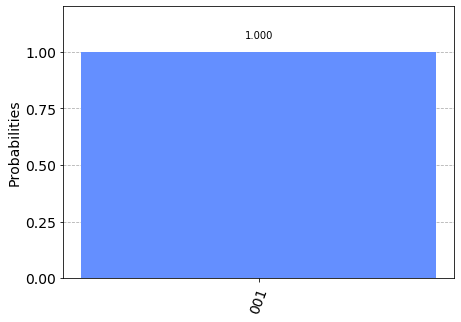

In [88]:
result2 = job2.result()
counts2 = result2.get_counts()
print(counts2)
plot_histogram(counts2)

{'001': 1}
